 ![picture](https://drive.google.com/uc?export=view&id=1KaUW3_JAieeY7WVNfoRiTSr2JsaeAcXi)

# **Reclutamiento de Empleados con Aprendizaje Automático | Colocación Laboral con Python | Sistema de Adquisición de Talento en RR.HH.**

En el mundo acelerado de hoy, las empresas buscan constantemente formas innovadoras para optimizar sus procesos, y la gestión de recursos humanos (RR.HH.) no es una excepción. Los métodos de reclutamiento tradicionales suelen ser consumidores de tiempo y carecen de la eficiencia necesaria para identificar a los mejores candidatos para el trabajo. Sin embargo, con los avances en aprendizaje automático y análisis de datos, los profesionales de RR.HH. ahora tienen herramientas poderosas a su disposición para revolucionar el proceso de reclutamiento.




## **Entendimiento del Proyecto:**
El proyecto está diseñado para aprovechar las técnicas de ML para predecir colocaciones laborales basadas en varios factores, como el rendimiento académico, la experiencia laboral, la especialización, y más.

Al analizar los datos históricos de empleados anteriores, el sistema busca identificar patrones y correlaciones que puedan predecir si un candidato es probable que sea colocado o no.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/germaingarcia/Files_Lectures/main/Placement_Data_Full_Class.csv")

In [3]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


## **Diccionario**

1. **Sl_no**: Número de serie o identificador único para cada entrada o persona.
2. **gender**: Género del individuo.
3. **ssc_p**: Porcentaje obtenido en los exámenes de secundaria (SSC suele referirse a Secondary School Certificate).
4. **ssc_b**: Junta o comité organizador de los exámenes de secundaria.
5. **hsc_p**: Porcentaje obtenido en los exámenes de educación superior secundaria (HSC se refiere a Higher Secondary Certificate).
6. **hsc_b**: Junta o comité organizador de los exámenes de educación superior secundaria.
7. **hsc_s**: Especialización o área de estudio en la educación superior secundaria (ciencias, comercio, arte, etc.).
8. **degree_p**: Porcentaje obtenido en el grado universitario.
9. **degree_t**: Tipo de grado o campo de estudio en la educación universitaria (por ejemplo, tecnología, artes, comercio).
10. **workex**: Experiencia laboral (generalmente indicado como 'Yes' o 'No').
11. **etest_p**: Porcentaje obtenido en un examen de prueba, posiblemente un examen de empleabilidad o habilidades específicas.
12. **specialisation**: Especialización en estudios de posgrado, especialmente en programas de MBA.
13. **mba_p**: Porcentaje obtenido en el programa de MBA.
14. **status**: Estado del empleo o resultado del proceso de selección (como 'employed' o 'unemployed').
15. **salary**: Salario ofrecido o actual del individuo.



In [4]:
df = df.drop(columns=['ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'salary'])
df.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,91.00,58.00,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,78.33,77.48,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,68.00,64.00,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,52.00,52.00,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,73.60,73.30,No,96.8,Mkt&Fin,55.50,Placed


## Preprocessing

## Encoding

 Limpiar y preparar el conjunto de datos para el análisis. Esto incluye manejar valores faltantes, codificar variables categóricas y escalar características numéricas.

In [5]:
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
df['workex'] = df['workex'].map({'Yes': 1, 'No': 0})
df['status'] = df['status'].map({'Placed': 1, 'Not Placed': 0})
df['specialisation'] = df['specialisation'].map({'Mkt&HR': 0, 'Mkt&Fin': 1})
df.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,1,67.00,91.00,58.00,0,55.0,0,58.80,1
1,2,1,79.33,78.33,77.48,1,86.5,1,66.28,1
2,3,1,65.00,68.00,64.00,0,75.0,1,57.80,1
3,4,1,56.00,52.00,52.00,0,66.0,0,59.43,0
4,5,1,85.80,73.60,73.30,0,96.8,1,55.50,1


# Balance Dataset


In [6]:
df['status'].value_counts()

status
1    148
0     67
Name: count, dtype: int64

In [7]:
from sklearn.utils import resample

# Separar la clase minoritaria de la clase mayoritaria
majority = df[df['status'] == 1]
minority = df[df['status'] == 0]

# Adicionar elementos de la clase minoritaria
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)

# Combinar clases mayoritarias y clases minoritarias en la variable balanced_data
balanced_data = pd.concat([majority, minority_upsampled])

In [8]:
balanced_data['status'].value_counts()

status
1    148
0    148
Name: count, dtype: int64

# Train Test Split

In [9]:
X = balanced_data.copy().drop('status', axis=1)
y = balanced_data['status']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(207, 9) (207,) (89, 9) (89,)


# Feature Scaling

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1 k-nearest neighbor

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)
Y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(Y_test, Y_pred_knn))
print(classification_report(Y_test, Y_pred_knn))

KNN Accuracy: 0.8314606741573034
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        39
           1       0.86      0.84      0.85        50

    accuracy                           0.83        89
   macro avg       0.83      0.83      0.83        89
weighted avg       0.83      0.83      0.83        89



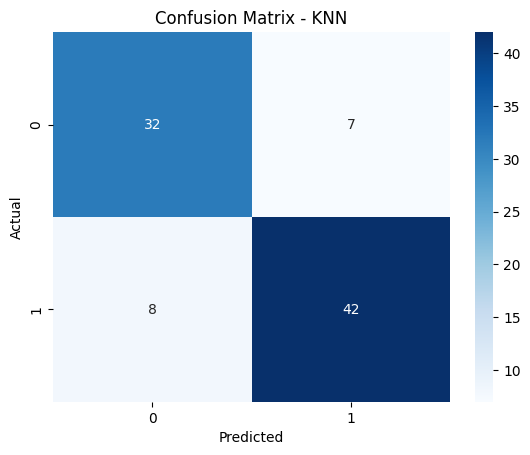

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_knn = confusion_matrix(Y_test, Y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Decision Tree

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)
Y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(Y_test, Y_pred_dt))
print(classification_report(Y_test, Y_pred_dt))

Decision Tree Accuracy: 0.9325842696629213
              precision    recall  f1-score   support

           0       0.97      0.87      0.92        39
           1       0.91      0.98      0.94        50

    accuracy                           0.93        89
   macro avg       0.94      0.93      0.93        89
weighted avg       0.94      0.93      0.93        89



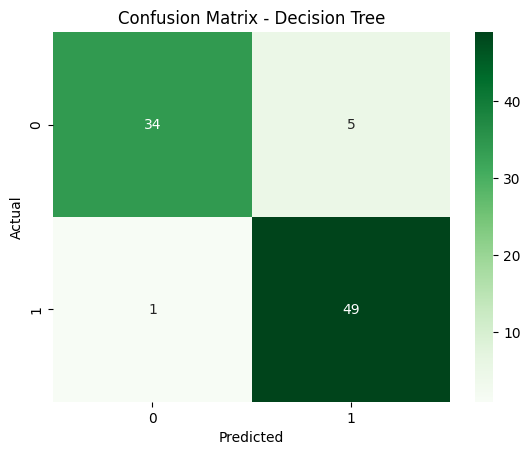

In [15]:
cm_dt = confusion_matrix(Y_test, Y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# SVM

In [16]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, Y_train)
Y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(Y_test, Y_pred_svm))
print(classification_report(Y_test, Y_pred_svm))

SVM Accuracy: 0.8651685393258427
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        39
           1       0.95      0.80      0.87        50

    accuracy                           0.87        89
   macro avg       0.87      0.87      0.87        89
weighted avg       0.88      0.87      0.87        89



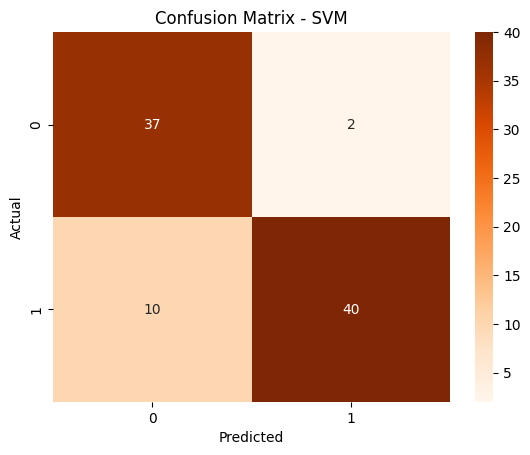

In [17]:
cm_svm = confusion_matrix(Y_test, Y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf))

Random Forest Accuracy: 0.898876404494382
              precision    recall  f1-score   support

           0       0.83      0.97      0.89        39
           1       0.98      0.84      0.90        50

    accuracy                           0.90        89
   macro avg       0.90      0.91      0.90        89
weighted avg       0.91      0.90      0.90        89



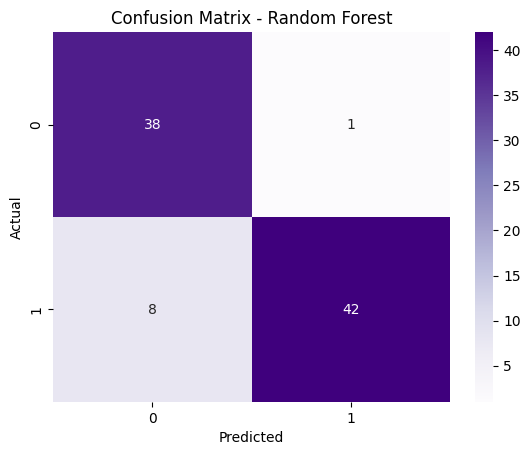

In [19]:
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Gaussian Naive Bayes

Gaussian Naive Bayes Accuracy: 0.7640449438202247


              precision    recall  f1-score   support

           0       0.70      0.79      0.75        39
           1       0.82      0.74      0.78        50

    accuracy                           0.76        89
   macro avg       0.76      0.77      0.76        89
weighted avg       0.77      0.76      0.76        89



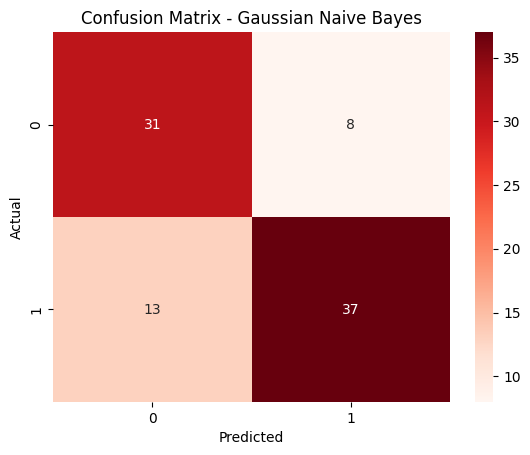

In [20]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, Y_train)
Y_pred_gnb = gnb.predict(X_test)

print("Gaussian Naive Bayes Accuracy:", accuracy_score(Y_test, Y_pred_gnb))
print(classification_report(Y_test, Y_pred_gnb))

cm_gnb = confusion_matrix(Y_test, Y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Logistic Regression

Logistic Regression Accuracy: 0.8089887640449438
              precision    recall  f1-score   support

           0       0.75      0.85      0.80        39
           1       0.87      0.78      0.82        50

    accuracy                           0.81        89
   macro avg       0.81      0.81      0.81        89
weighted avg       0.82      0.81      0.81        89



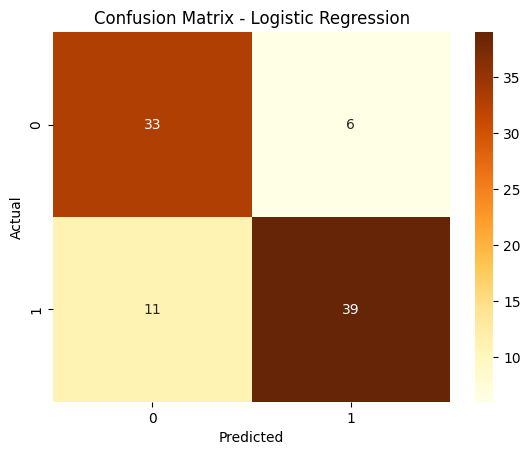

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(Y_test, Y_pred_lr))
print(classification_report(Y_test, Y_pred_lr))

cm_lr = confusion_matrix(Y_test, Y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='YlOrBr')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Single Input Predictions

Test si está prediciendo adecuadamente

In [22]:
sample = X_test[0].reshape(1, -1)
predicted = rf.predict(sample)[0]
actual = Y_test.iloc[0]

print(f"Predicted Class : {predicted}")
print(f"Actual Class: {actual}")

Predicted Class : 0
Actual Class: 0


# Sistema de Predicción

In [23]:
def prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p):
    gender_enc = 1 if gender == "M" else 0
    workex_enc = 1 if workex == "Yes" else 0
    specialisation_enc = 1 if specialisation == "Mkt&Fin" else 0

    # arreglado mismatch
    input_data = pd.DataFrame(
        [[sl_no, gender_enc, ssc_p, hsc_p, degree_p, workex_enc, etest_p, specialisation_enc, mba_p]],
        columns=["sl_no", "gender", "ssc_p", "hsc_p", "degree_p", "workex", "etest_p", "specialisation", "mba_p"]
    )
    input_scaled = scaler.transform(input_data)
    result = rf.predict(input_scaled)[0]
    return result

In [24]:
sl_no =11
gender = "F"
ssc_p =58.
hsc_p = 61.
degree_p = 60.
workex = "Yes"
etest_p = 62.
specialisation = "Mkt&Fin"
mba_p = 60.85

result = prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p)

if result == 1:
    print('contratado')

else:
    print('No Contratado')

No Contratado



Se emplea un modelo de Clasificador Random Forest para predecir las colocaciones laborales basadas en características de entrada como los puntajes académicos, la experiencia laboral y otros factores relevantes. El modelo se entrena con datos históricos para aprender patrones y hacer predicciones precisas.

# Guardar Archivos

In [25]:
import pickle

with open('model_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Modelo guardado exitosamente.")

Modelo guardado exitosamente.
